# IPL Data Analysis (2008-2024)
**Tools:** Python, Pandas, Seaborn, Matplotlib

**Dataset:** 1095 matches, 260,920 deliveries

**key findings:**
- Mumbai Indians most successful IPL Team
- Toss winning has minimal impact on match outcome
- AB de Villiers - most Player of the Match awards
- IPL scoring has grow 45% from 2008 to 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [3]:
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [4]:
print("\nMatches Columns:",matches.columns.tolist())
print("\nFirst 5 rowa:")
matches.head()


Matches Columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

First 5 rowa:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


### Most IPL Matches Won by Each Team

C:\Users\sharukh khan\AppData\Local\Temp\ipykernel_22616\2321652178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')


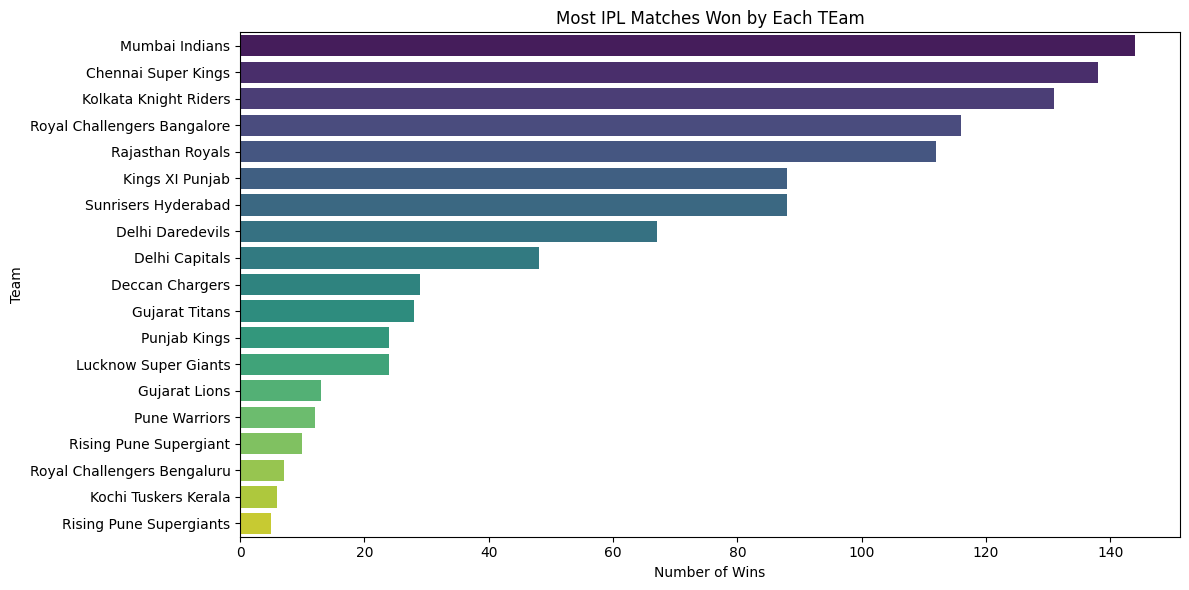

In [5]:
plt.figure(figsize=(12,6))
top_winners = matches['winner'].value_counts()
sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')
plt.title('Most IPL Matches Won by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

### Toss Winner = Match Winner?

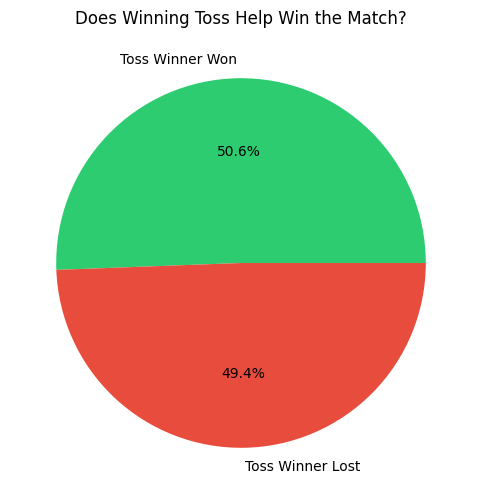

In [8]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_effect = matches['toss_match_winner'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(toss_effect.values,
        labels=['Toss Winner Won', 'Toss Winner Lost'],
        autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'])
plt.title('Does Winning Toss Help Win the Match?')
plt.show()

### Top 10 Player of the Match

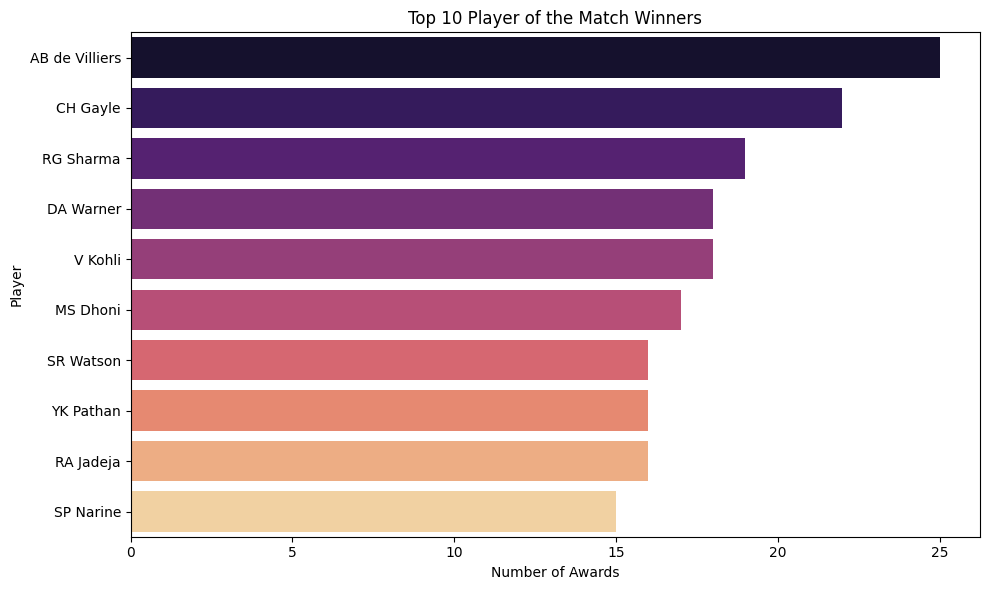

In [11]:
# Man of the Match
plt.figure(figsize=(10,6))
top_players = matches['player_of_match'].value_counts().head(10)
sns.barplot(x=top_players.values, y=top_players.index,
            hue=top_players.index, palette='magma', legend=False)
plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

### Season wise Total runs

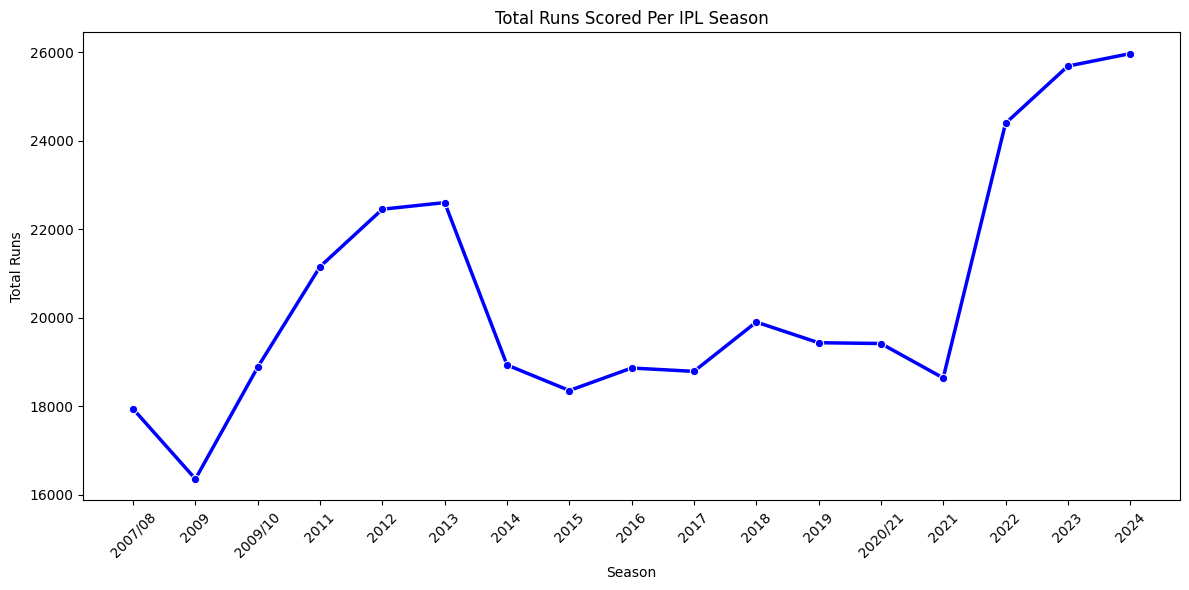

In [16]:
season_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
season_runs = season_runs.merge(matches[['id','season']],
                               left_on='match_id',right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(x=season_total.index, y=season_total.values,
             marker='o', color='blue', linewidth=2.5)
plt.title('Total Runs Scored Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Batting first vs second win rate

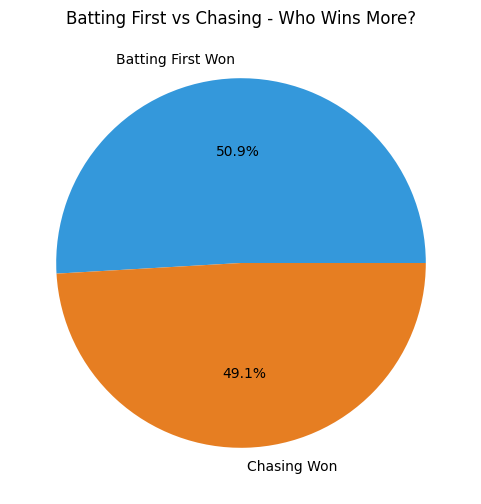

In [17]:
batting_first = matches[matches['winner'] == matches['team1']].shape[0]
batting_second = matches[matches['winner'] == matches['team2']].shape[0]

plt.figure(figsize=(6,6))
plt.pie([batting_first, batting_second],
        labels=['Batting First Won', 'Chasing Won'],
        autopct='%1.1f%%',
        colors=['#3498db','#e67e22'])
plt.title('Batting First vs Chasing - Who Wins More?')
plt.show()